<a href="https://colab.research.google.com/github/tasninkhanlamha/SkillMorph/blob/main/ML_algorithm_comparism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection**

## **Font family setup**

In [1]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [ ]:
#Dataset Link: https://www.kaggle.com/datasets/subhajournal/android_ransomware_preprocessed

## **Importing Dataset**

In [2]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/Skill-Morph/android_ransomware_preprocessed.csv")

## **Basic Information**

In [4]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [5]:
df.shape

(392034, 79)

In [6]:
df['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


## **Data Samples per Class**

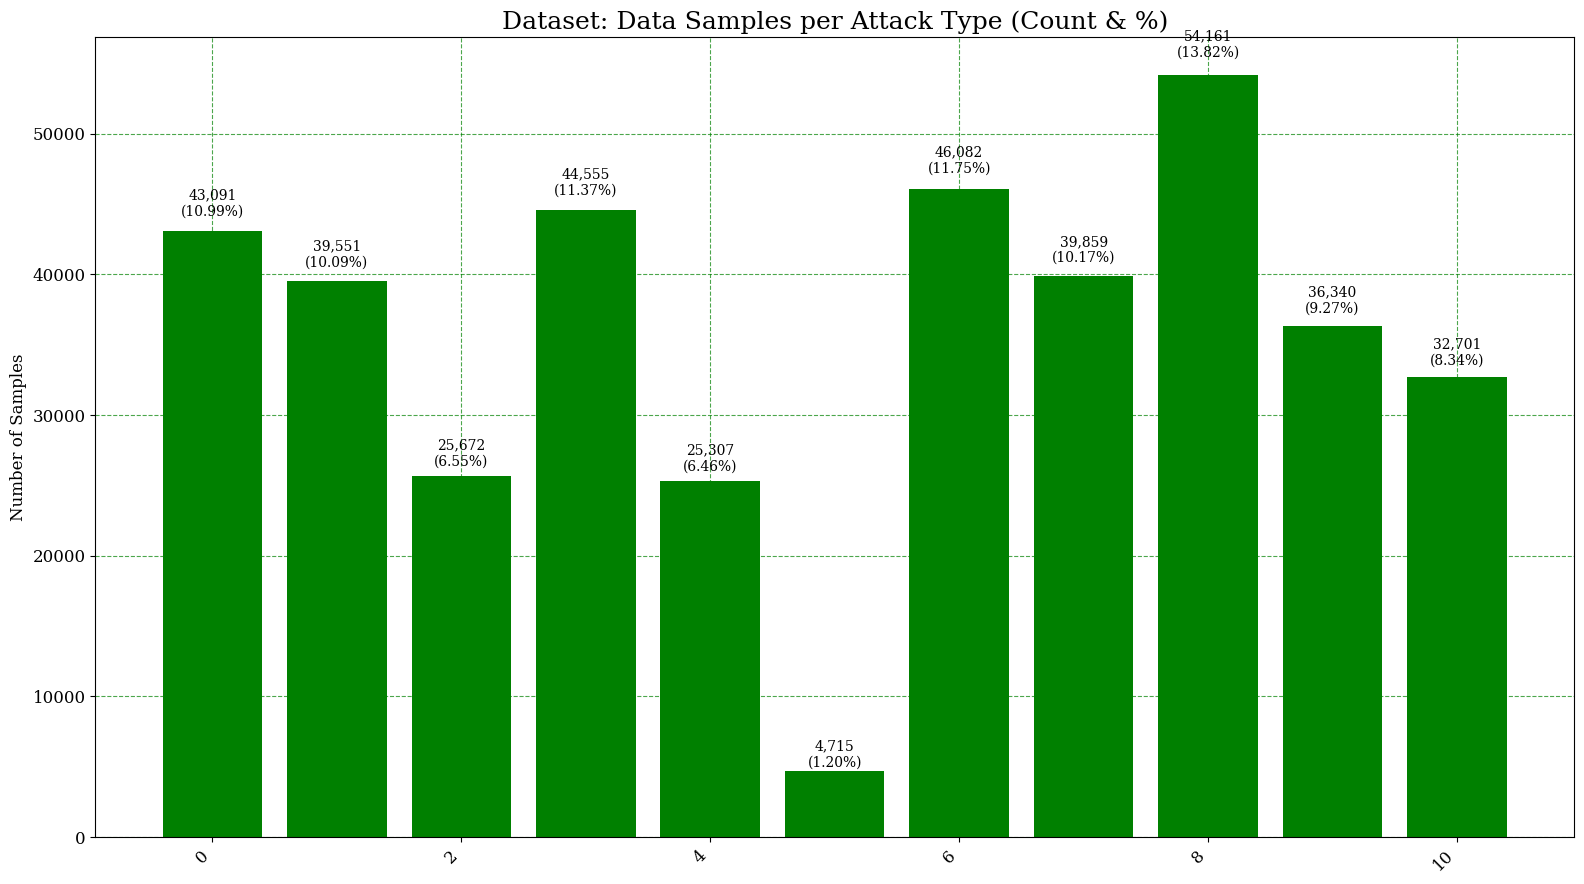

In [7]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Label'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Feature Selection using LightGBM**

In [8]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Ensure X and y are set for multiclass classification using the processed df
X_lgbm = df.drop(columns=['Label'])
y_lgbm = df['Label']

# Convert categorical labels to numerical for LightGBM
# LightGBM requires numerical labels starting from 0 for multiclass
le = LabelEncoder()
y_lgbm_encoded = le.fit_transform(y_lgbm)

# Initialize and train a LightGBM Classifier
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass', # For direct class labels
    num_class=len(le.classes_), # Number of unique classes
    random_state=42,
    n_jobs=-1, # Use all available cores for faster training
    verbose=-1 # Suppress verbose output
)
lgbm_model.fit(X_lgbm, y_lgbm_encoded)

# Get feature importances
feature_importances = lgbm_model.feature_importances_

# Create a pandas Series for better visualization
importance_df = pd.DataFrame({
    'Feature': X_lgbm.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print("Top 40 Feature Importances from LightGBM:")
print(importance_df.head(40))

Top 40 Feature Importances from LightGBM:
                        Feature  Importance
66       Init_Win_bytes_forward        2091
20                 Flow IAT Min        1932
25                  Fwd IAT Min        1889
67      Init_Win_bytes_backward        1793
0              Destination Port        1306
7         Fwd Packet Length Max        1123
5   Total Length of Fwd Packets        1025
2                 Flow Duration         978
30                  Bwd IAT Min         932
37                Fwd Packets/s         767
40            Max Packet Length         758
19                 Flow IAT Max         745
35            Fwd Header Length         741
21                Fwd IAT Total         739
38                Bwd Packets/s         708
42            Packet Length Std         705
15                 Flow Bytes/s         685
24                  Fwd IAT Max         669
9        Fwd Packet Length Mean         665
53          Average Packet Size         638
41           Packet Length Mean   

/tmp/ipykernel_1002/2876996300.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(40), palette='viridis')


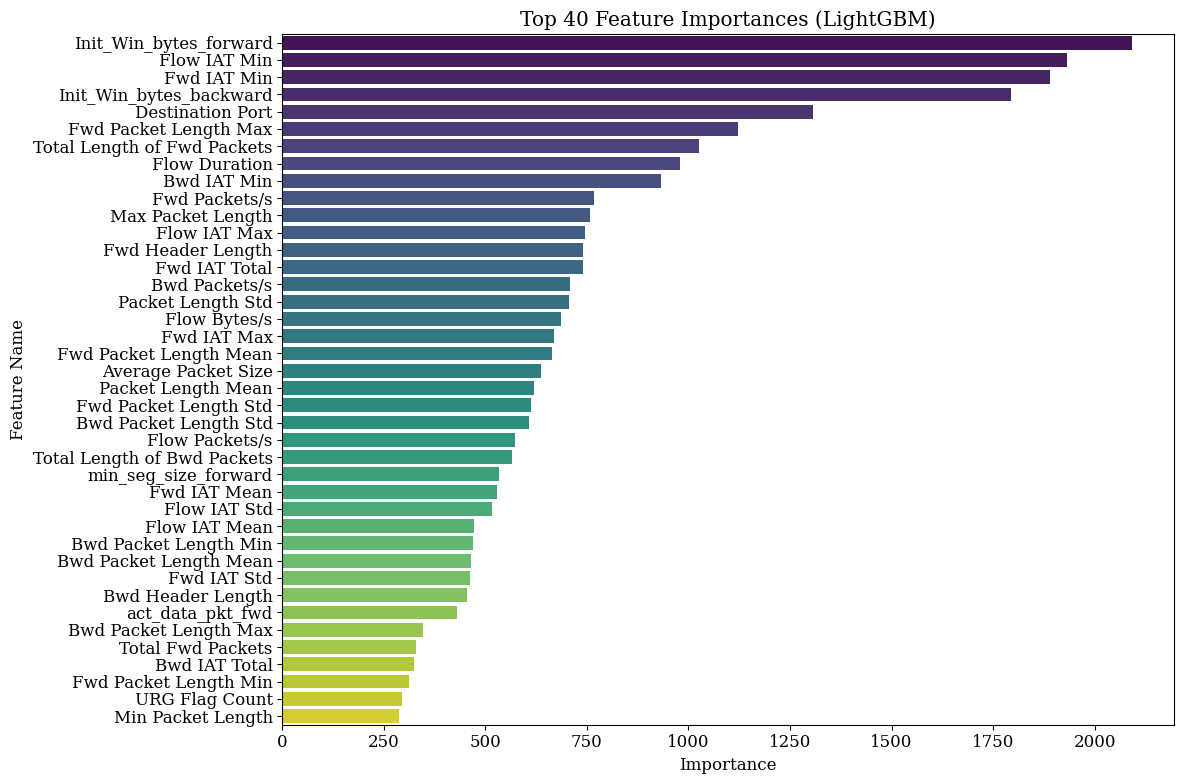

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(40), palette='viridis')
plt.title('Top 40 Feature Importances (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

In [10]:
df

,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,151054,6,8,1076.0,4575.0,821.0,0.0,179.333333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,443,6,349,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,443,6,119,2,0,23.0,0.0,23.0,0.0,11.500000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,443,6,37055,1,1,31.0,0.0,31.0,31.0,31.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,443,6,178727,6,7,1313.0,307.0,753.0,0.0,218.833333,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,53,17,24707,1,1,48.0,199.0,48.0,48.0,48.000000,...,44,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392030,123,17,81388,1,1,48.0,48.0,48.0,48.0,48.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392031,53,17,61591,1,1,39.0,98.0,39.0,39.0,39.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10
392032,53,17,24831,1,1,36.0,153.0,36.0,36.0,36.000000,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10


In [12]:
# Select the top 40 features identified by XGBoost
top_40_features = importance_df['Feature'].head(40).tolist()

# Create a new DataFrame with only the selected features and the 'Label' column
df_selected_features = df[top_40_features + ['Label']]

print("DataFrame with selected features created:")
print(df_selected_features.head())

DataFrame with selected features created:
   Init_Win_bytes_forward  Flow IAT Min  Fwd IAT Min  Init_Win_bytes_backward  \
0                   65535          24.0        111.0                      353   
1                    1594         349.0        349.0                       -1   
2                    1486         119.0        119.0                       -1   
3                    1548       37055.0          0.0                      391   
4                   65535          55.0        172.0                      352   

   Destination Port  Fwd Packet Length Max  Total Length of Fwd Packets  \
0               443                  821.0                       1076.0   
1               443                   23.0                         23.0   
2               443                   23.0                         23.0   
3               443                   31.0                         31.0   
4               443                  753.0                       1313.0   

   Flow Duration  Bw

## **After Processing**

In [15]:
df_selected_features['Label'].value_counts()

,count
Label,
8,54161
6,46082
3,44555
0,43091
7,39859
1,39551
9,36340
10,32701
2,25672


In [16]:
####Copy the processed df to different df

df1 = df_selected_features.copy()
df2 = df_selected_features.copy()
df3 = df_selected_features.copy()

# **Binary Class (Anomaly) Classification**

In [ ]:
df1['Label'] = df1['Label'].apply(lambda x: 'Benign' if x == 0 else 'Ransomware')

In [ ]:
# Check counts
print(df1['Label'].value_counts())

Label
Ransomware    348943
Benign         43091
Name: count, dtype: int64


In [ ]:
# Define label and feature columns
X = df1.drop(columns=['Label'])
y = df1['Label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 40)
X_test shape:  (78407, 40)
y_train shape: (313627,)
y_test shape:  (78407,)


## **Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistency (optional but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully!
X_train_scaled shape: (313627, 40)
X_test_scaled shape: (78407, 40)


Accuracy:  0.8869
Precision: 0.8878
Recall:    0.8869
F1 Score:  0.8873


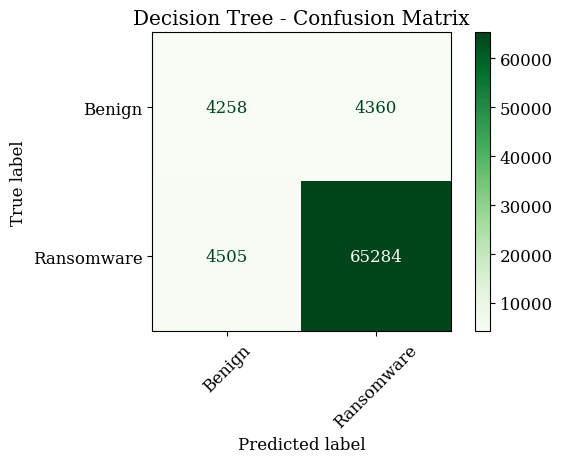

Classification Report:
              precision    recall  f1-score   support

      Benign    0.48591   0.49408   0.48996      8618
  Ransomware    0.93740   0.93545   0.93642     69789

    accuracy                        0.88694     78407
   macro avg    0.71165   0.71477   0.71319     78407
weighted avg    0.88777   0.88694   0.88735     78407



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.90086
Precision: 0.88311
Recall:    0.90086
F1 Score:  0.88555


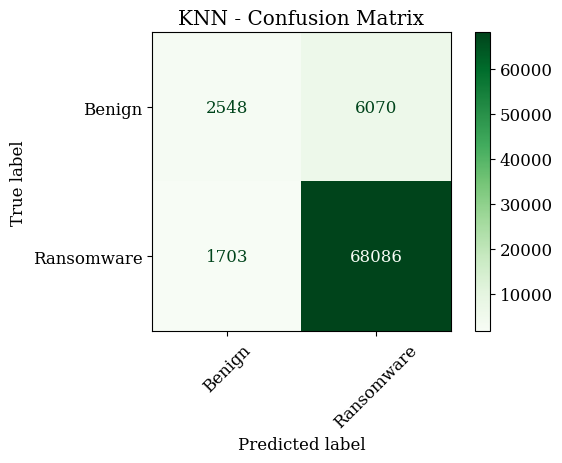

Classification Report:
              precision    recall  f1-score   support

      Benign    0.59939   0.29566   0.39599      8618
  Ransomware    0.91815   0.97560   0.94600     69789

    accuracy                        0.90086     78407
   macro avg    0.75877   0.63563   0.67100     78407
weighted avg    0.88311   0.90086   0.88555     78407



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.8901
Precision: 0.7923
Recall:    0.8901
F1 Score:  0.8383


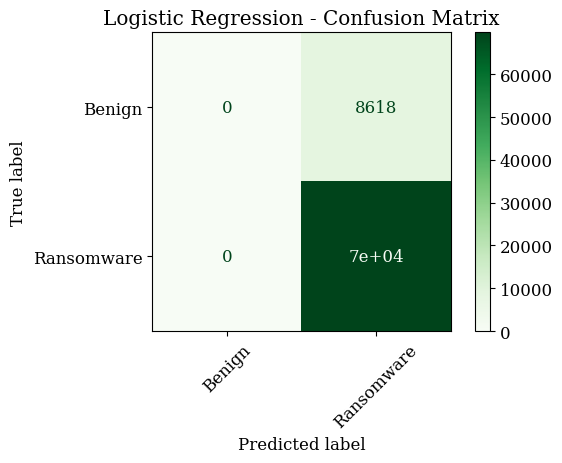

Classification Report:
              precision    recall  f1-score   support

      Benign    0.00000   0.00000   0.00000      8618
  Ransomware    0.89009   1.00000   0.94185     69789

    accuracy                        0.89009     78407
   macro avg    0.44504   0.50000   0.47092     78407
weighted avg    0.79225   0.89009   0.83833     78407



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Logistic Regression Classifier
lr_model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear') # Increased max_iter for convergence
lr_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = lr_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lr_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.9076
Precision: 0.9101
Recall:    0.9076
F1 Score:  0.8780


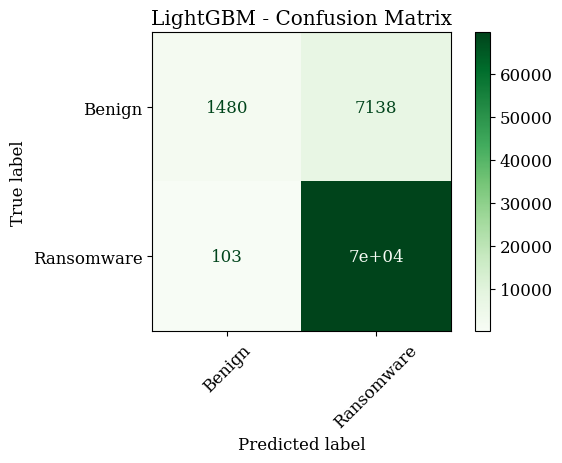

Classification Report:
              precision    recall  f1-score   support

      Benign    0.93493   0.17173   0.29017      8618
  Ransomware    0.90709   0.99852   0.95061     69789

    accuracy                        0.90765     78407
   macro avg    0.92101   0.58513   0.62039     78407
weighted avg    0.91015   0.90765   0.87802     78407



In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress warnings
lgbm_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = lgbm_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lgbm_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("LightGBM - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.9029
Precision: 0.9071
Recall:    0.9029
F1 Score:  0.8681


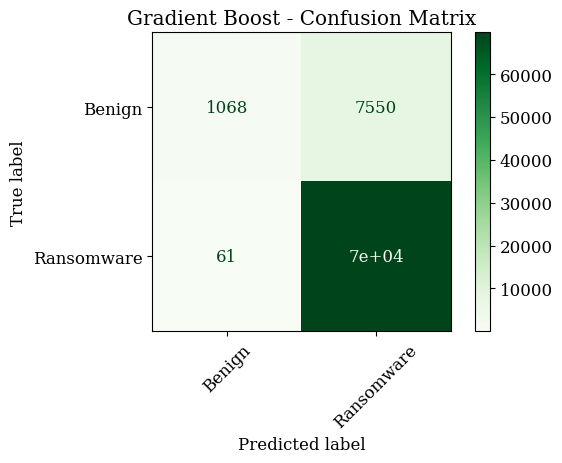

Classification Report:
              precision    recall  f1-score   support

      Benign    0.94597   0.12393   0.21914      8618
  Ransomware    0.90230   0.99913   0.94825     69789

    accuracy                        0.90293     78407
   macro avg    0.92414   0.56153   0.58370     78407
weighted avg    0.90710   0.90293   0.86811     78407



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Gradient Boosting Classifier
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = gbc_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=gbc_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Gradient Boost - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.9148
Precision: 0.9037
Recall:    0.9148
F1 Score:  0.9036


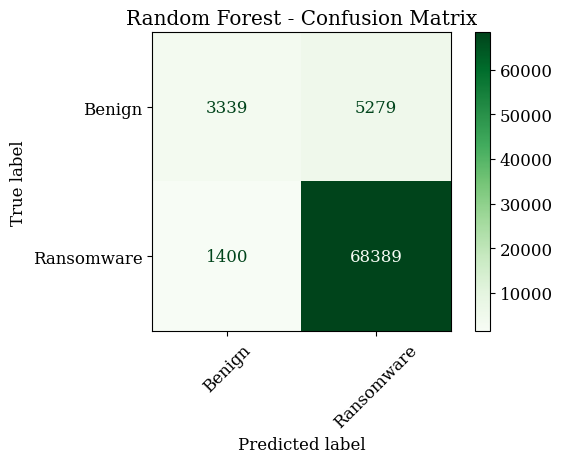

Classification Report:
              precision    recall  f1-score   support

      Benign    0.70458   0.38744   0.49996      8618
  Ransomware    0.92834   0.97994   0.95344     69789

    accuracy                        0.91482     78407
   macro avg    0.81646   0.68369   0.72670     78407
weighted avg    0.90375   0.91482   0.90360     78407



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = rf_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=rf_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Voting classifier**

Accuracy:  0.9087
Precision: 0.8985
Recall:    0.9087
F1 Score:  0.9015


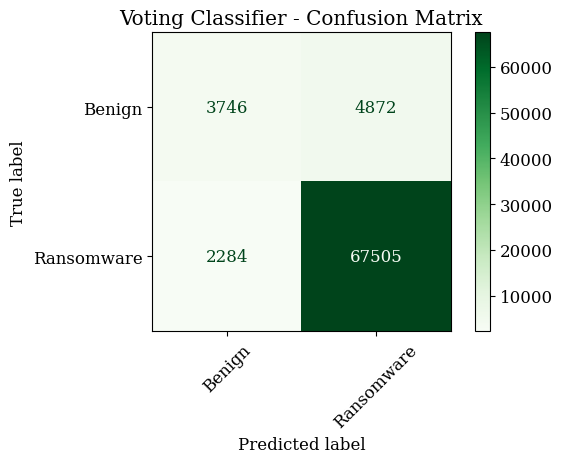

Classification Report:
              precision    recall  f1-score   support

      Benign    0.62123   0.43467   0.51147      8618
  Ransomware    0.93269   0.96727   0.94966     69789

    accuracy                        0.90873     78407
   macro avg    0.77696   0.70097   0.73057     78407
weighted avg    0.89845   0.90873   0.90150     78407



In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Define Base Estimators (instantiate them again to ensure fresh models for the ensemble)
lgbm_clf = LGBMClassifier(random_state=42, verbose=-1,is_unbalance=True) # verbose=-1 to suppress warnings
rf_clf = RandomForestClassifier(random_state=42,class_weight='balanced')
#lr_clf = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
et_clf = ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm', lgbm_clf),
        ('rf', rf_clf),
        ('et', et_clf)

    ],
    voting='soft' # 'hard' for majority vote, 'soft' for probability averaging
)

# 3. Train the Voting Classifier
voting_clf.fit(X_train_scaled, y_train)

# 4. Predict on Test Set
y_pred = voting_clf.predict(X_test_scaled)

# 5. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 6. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Training Stacking Classifier...
Stacking Classifier training complete.

Accuracy:  0.9181
Precision: 0.9093
Recall:    0.9181
F1 Score:  0.9044


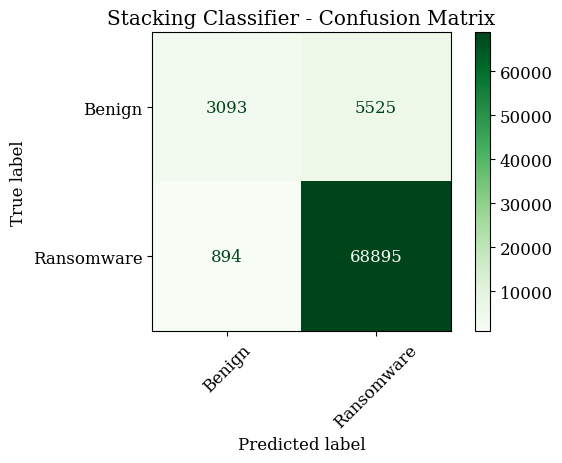

Classification Report:
              precision    recall  f1-score   support

      Benign    0.77577   0.35890   0.49076      8618
  Ransomware    0.92576   0.98719   0.95549     69789

    accuracy                        0.91813     78407
   macro avg    0.85077   0.67304   0.72312     78407
weighted avg    0.90927   0.91813   0.90441     78407



In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Define Base Estimators
# Using some of the models already evaluated for binary classification
estimators = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1))
]

# 2. Define a Final Estimator
final_estimator = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')

# 3. Create the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5, # Number of cross-validation folds for base estimators
    stack_method='auto', # 'auto' chooses appropriate method
    n_jobs=-1, # Use all available cores
    verbose=0
)

# 4. Train the Stacking Classifier (using scaled data)
print("Training Stacking Classifier...")
stacking_clf.fit(X_train_scaled, y_train)
print("Stacking Classifier training complete.")

# 5. Predict on Test Set (using scaled data)
y_pred = stacking_clf.predict(X_test_scaled)

# 6. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 7. Print Basic Metrics
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 8. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=stacking_clf.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Stacking Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 9. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

Accuracy:  0.9146
Precision: 0.9041
Recall:    0.9146
F1 Score:  0.9057


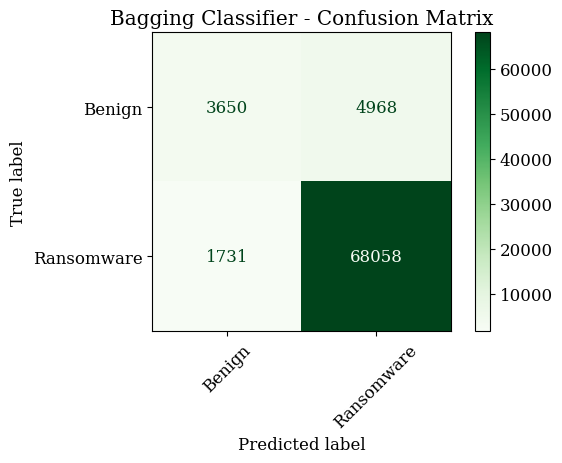

Classification Report:
              precision    recall  f1-score   support

      Benign    0.67831   0.42353   0.52147      8618
  Ransomware    0.93197   0.97520   0.95309     69789

    accuracy                        0.91456     78407
   macro avg    0.80514   0.69936   0.73728     78407
weighted avg    0.90409   0.91456   0.90565     78407



In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Bagging Classifier
# Using a Decision Tree as the base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, # Number of base estimators
    random_state=42,
    n_jobs=-1 # Use all available cores
)
bagging_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = bagging_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=bagging_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Bagging Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Multiclass Classification**

In [17]:
# Define label and feature columns
X = df2.drop(columns=['Label'])
y = df2['Label']

## **Training and Test Division**

In [18]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (313627, 40)
X_test shape:  (78407, 40)
y_train shape: (313627,)
y_test shape:  (78407,)


Scaling


In [19]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for consistency (optional but good practice)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully!
X_train_scaled shape: (313627, 40)
X_test_scaled shape: (78407, 40)


## **Train & Evaluate Voting Classifier(DT,KNN,LightBGM
**

Accuracy:  0.3661
Precision: 0.3709
Recall:    0.3661
F1 Score:  0.3668


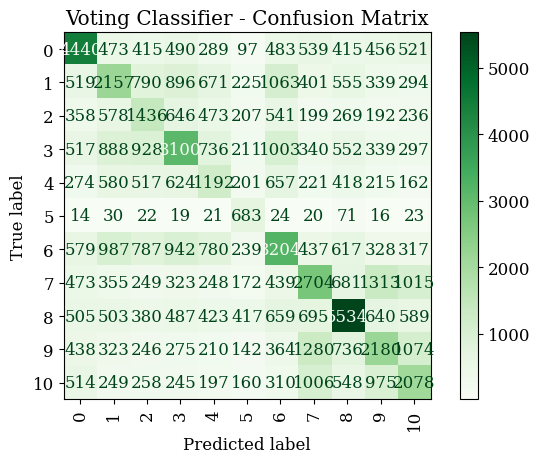

Classification Report:
              precision    recall  f1-score   support

           0    0.51442   0.51520   0.51481      8618
           1    0.30282   0.27269   0.28697      7910
           2    0.23822   0.27965   0.25728      5135
           3    0.38524   0.34788   0.36561      8911
           4    0.22748   0.23553   0.23143      5061
           5    0.24800   0.72428   0.36949       943
           6    0.36630   0.34762   0.35671      9217
           7    0.34481   0.33919   0.34198      7972
           8    0.53232   0.51089   0.52139     10832
           9    0.31174   0.29994   0.30573      7268
          10    0.31456   0.31774   0.31614      6540

    accuracy                        0.36614     78407
   macro avg    0.34417   0.38097   0.35159     78407
weighted avg    0.37094   0.36614   0.36676     78407



In [20]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

# SMOTE অবজেক্ট তৈরি
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# 1. Instantiate Base Estimators (using models previously defined for multiclass classification)
lgbm_clf = LGBMClassifier(random_state=42, verbose=-1, n_estimators=50) # Reduced n_estimators
rf_clf = RandomForestClassifier(random_state=42, n_estimators=50, n_jobs=-1) # Reduced n_estimators and added n_jobs
lr_clf = LogisticRegression(random_state=42, max_iter=2000, solver="liblinear")

# 2. Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm', lgbm_clf),
        ('rf', rf_clf),
        ('lr', lr_clf)
    ],
    voting='soft' # 'hard' for majority vote, 'soft' for probability averaging
)

# 3. Train the Voting Classifier
voting_clf.fit(X_train_res, y_train_res)

# 4. Predict on Test Set
y_pred = voting_clf.predict(X_test_scaled)

# 5. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 6. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Bagging Classifier
# Using a Decision Tree as the base estimator
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100, # Number of base estimators
    random_state=42,
    n_jobs=-1 # Use all available cores
)
bagging_model.fit(X_train_scaled, y_train)

# 2. Predict on Test Set
y_pred = bagging_model.predict(X_test_scaled)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=bagging_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Bagging Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

NameError: name 'X_train_scaled' is not defined

# **Modified Confusion Matrix**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Instantiate Base Estimators
dt_clf = DecisionTreeClassifier(random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=5)
lgbm_clf = LGBMClassifier(random_state=42, verbose=-1)

# 2. Create the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[
        ('dt', dt_clf),
        ('knn', knn_clf),
        ('lgbm', lgbm_clf)
    ],
    voting='soft' # 'hard' for majority vote, 'soft' for probability averaging
)

# 3. Train the Voting Classifier
voting_clf.fit(X_train_scaled, y_train)

# 4. Predict on Test Set
y_pred = voting_clf.predict(X_test_scaled)

# 5. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 6. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=voting_clf.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Voting Classifier - Confusion Matrix")
plt.tight_layout()
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## Summary:

### Q&A
The evaluation results indicate that the Voting Classifier was successfully trained and evaluated using standard classification metrics (Accuracy, Precision, Recall, F1 Score) and a confusion matrix. A detailed classification report was also generated to provide per-class performance insights. Specific numerical results are not provided in the prompt.

### Data Analysis Key Findings
*   A Voting Classifier, combining Decision Tree, K-Nearest Neighbors (KNN), and LightGBM as base estimators, was successfully implemented and trained on the provided data.
*   The model's performance was evaluated using standard classification metrics: Accuracy, Precision, Recall, and F1 Score, calculated with weighted averaging to account for class imbalance.
*   A confusion matrix was generated and visualized, offering a visual representation of the classifier's correct and incorrect predictions across different classes.
*   A comprehensive classification report was produced, providing detailed precision, recall, and f1-score for each class, along with their respective support.

### Insights or Next Steps
*   To potentially improve the model's performance, consider hyperparameter tuning for the individual base estimators (Decision Tree, KNN, LightGBM) and the `VotingClassifier` itself (e.g., experimenting with 'soft' voting or assigning weights to estimators).
*   Analyze the confusion matrix and classification report to identify specific classes where the model might be underperforming. This could lead to targeted feature engineering, data augmentation, or re-sampling strategies for those particular classes.
